In [1]:
import os
from scipy.io import loadmat

cwru_folder = r"C:\MachineHealthProject\data\CWRU"

# List all .mat files
cwru_files = [
    os.path.join(cwru_folder, f)
    for f in os.listdir(cwru_folder)
    if f.endswith(".mat")
]

print("CWRU files found:")
for file in cwru_files:
    print(os.path.basename(file))

print("\nTotal files:", len(cwru_files))

CWRU files found:
105.mat
118.mat
130.mat
97.mat

Total files: 4


In [2]:
data = loadmat(r"C:\MachineHealthProject\data\CWRU\97.mat")

print("Variables inside 97.mat:")
print(data.keys())

Variables inside 97.mat:
dict_keys(['__header__', '__version__', '__globals__', 'X097_DE_time', 'X097_FE_time', 'X097RPM'])


In [3]:
import numpy as np

# Extract Drive End vibration signal
de_signal = data["X097_DE_time"].flatten()

# Extract Fan End vibration signal
fe_signal = data["X097_FE_time"].flatten()

# Extract RPM
rpm = data["X097RPM"].flatten()

print("Drive End signal length:", len(de_signal))
print("Fan End signal length:", len(fe_signal))
print("RPM:", rpm)

print("\nFirst 10 Drive End values:")
print(de_signal[:10])

print("\nFirst 10 Fan End values:")
print(fe_signal[:10])

Drive End signal length: 243938
Fan End signal length: 243938
RPM: [1796]

First 10 Drive End values:
[ 0.05319692  0.08866154  0.09971815  0.05862092 -0.00458954 -0.056952
 -0.07176369 -0.05862092 -0.04652123 -0.04985908]

First 10 Fan End values:
[ 0.14566727  0.09779636  0.05485636  0.03698182  0.05444545  0.02116182
 -0.00369818 -0.01068364  0.02938     0.10457636]


In [4]:
import numpy as np
import pandas as pd

sampling_rate = 12000  # CWRU Drive End sampling rate

# Basic statistics
print("Sampling rate:", sampling_rate, "Hz")
print("RPM:", rpm[0])

print("\n--- Drive End ---")
print("Number of samples:", len(de_signal))
print("Duration:", len(de_signal) / sampling_rate, "seconds")
print("Minimum:", np.min(de_signal))
print("Maximum:", np.max(de_signal))
print("Mean:", np.mean(de_signal))
print("Median:", np.median(de_signal))
print("Standard deviation:", np.std(de_signal))
print("RMS:", np.sqrt(np.mean(de_signal**2)))

print("\n--- Fan End ---")
print("Number of samples:", len(fe_signal))
print("Duration:", len(fe_signal) / sampling_rate, "seconds")
print("Minimum:", np.min(fe_signal))
print("Maximum:", np.max(fe_signal))
print("Mean:", np.mean(fe_signal))
print("Median:", np.median(fe_signal))
print("Standard deviation:", np.std(fe_signal))
print("RMS:", np.sqrt(np.mean(fe_signal**2)))

Sampling rate: 12000 Hz
RPM: 1796

--- Drive End ---
Number of samples: 243938
Duration: 20.328166666666668 seconds
Minimum: -0.28663753846153844
Maximum: 0.31125415384615385
Mean: 0.012558211199945506
Median: 0.012516923076923077
Standard deviation: 0.0726870986839877
RMS: 0.07376396805784112

--- Fan End ---
Number of samples: 243938
Duration: 20.328166666666668 seconds
Minimum: -0.24613454545454547
Maximum: 0.3574909090909091
Mean: 0.031375814316454476
Median: 0.029174545454545453
Standard deviation: 0.07864540858656546
RMS: 0.08467314813899654


In [5]:
import numpy as np

print("=== Drive End Signal ===")
print("NaN values:", np.isnan(de_signal).sum())
print("Infinite values:", np.isinf(de_signal).sum())

print("\n=== Fan End Signal ===")
print("NaN values:", np.isnan(fe_signal).sum())
print("Infinite values:", np.isinf(fe_signal).sum())

print("\n=== Duplicate values ===")
print("Drive End duplicate samples:", len(de_signal) - len(np.unique(de_signal)))
print("Fan End duplicate samples:", len(fe_signal) - len(np.unique(fe_signal)))

=== Drive End Signal ===
NaN values: 0
Infinite values: 0

=== Fan End Signal ===
NaN values: 0
Infinite values: 0

=== Duplicate values ===
Drive End duplicate samples: 241683
Fan End duplicate samples: 241439


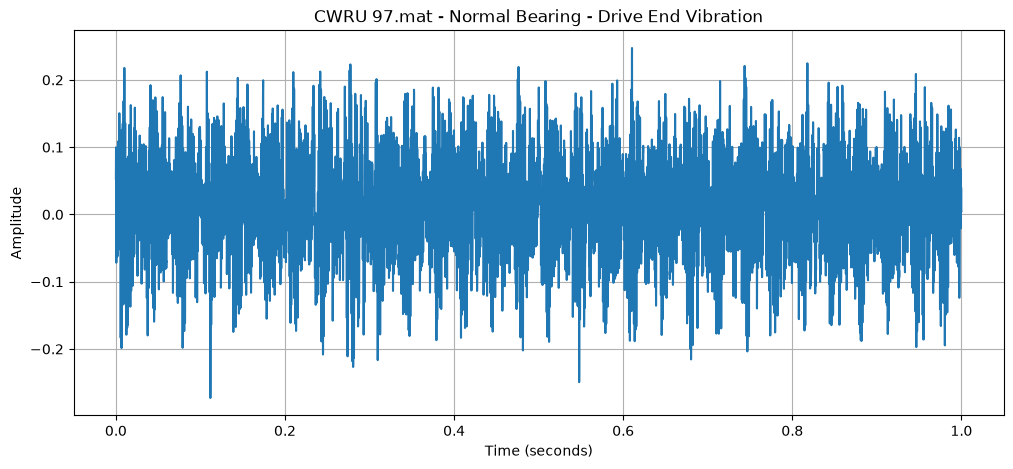

In [6]:
import matplotlib.pyplot as plt

# Show first 1 second of Drive End signal
samples_1sec = sampling_rate

time = np.arange(samples_1sec) / sampling_rate

plt.figure(figsize=(12, 5))
plt.plot(time, de_signal[:samples_1sec])
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("CWRU 97.mat - Normal Bearing - Drive End Vibration")
plt.grid(True)
plt.show()

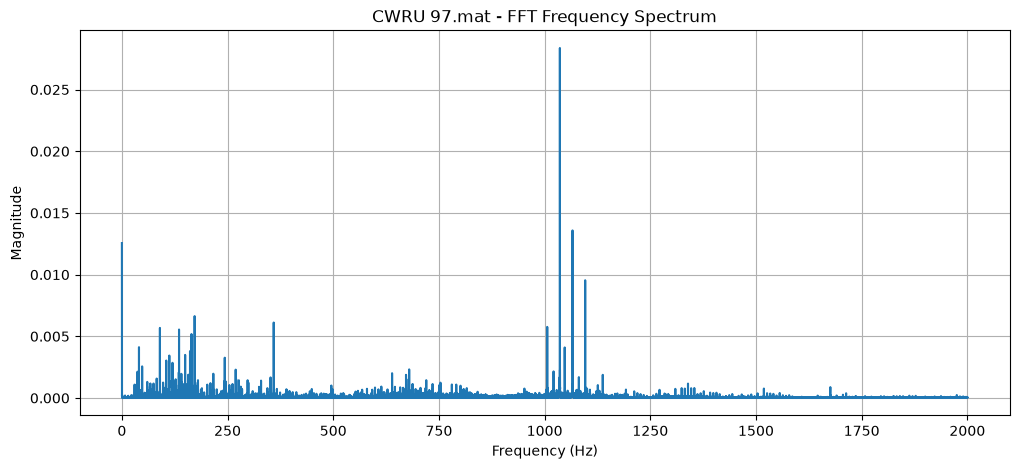

Top 10 frequency components:
1036.10 Hz -> Magnitude: 0.028369
1066.01 Hz -> Magnitude: 0.013583
1066.06 Hz -> Magnitude: 0.013286
1095.97 Hz -> Magnitude: 0.009544
2102.16 Hz -> Magnitude: 0.008842
172.08 Hz -> Magnitude: 0.006638
1036.15 Hz -> Magnitude: 0.006560
359.16 Hz -> Magnitude: 0.006116
1006.19 Hz -> Magnitude: 0.005763
89.97 Hz -> Magnitude: 0.005680


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Use the complete Drive End signal
signal = de_signal
N = len(signal)

# FFT
fft_values = np.fft.rfft(signal)
frequencies = np.fft.rfftfreq(N, d=1/sampling_rate)

# Magnitude
magnitude = np.abs(fft_values) / N

# Plot frequency spectrum up to 2000 Hz
max_frequency = 2000
mask = frequencies <= max_frequency

plt.figure(figsize=(12, 5))
plt.plot(frequencies[mask], magnitude[mask])

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("CWRU 97.mat - FFT Frequency Spectrum")
plt.grid(True)
plt.show()

# Find the strongest frequency components
peak_indices = np.argsort(magnitude[1:])[-10:] + 1
peak_indices = peak_indices[np.argsort(magnitude[peak_indices])[::-1]]

print("Top 10 frequency components:")
for i in peak_indices:
    print(f"{frequencies[i]:.2f} Hz -> Magnitude: {magnitude[i]:.6f}")

In [8]:
import pandas as pd
import numpy as np

# Extract features from the normal bearing signal
cwru_97_features = {
    "File": "97.mat",
    "Label": "Normal",
    "RPM": float(rpm[0]),
    "Sampling_Rate": sampling_rate,

    "Samples": len(de_signal),
    "Duration": len(de_signal) / sampling_rate,

    "Mean": np.mean(de_signal),
    "Median": np.median(de_signal),
    "Std": np.std(de_signal),
    "Min": np.min(de_signal),
    "Max": np.max(de_signal),

    "RMS": np.sqrt(np.mean(de_signal ** 2)),

    "Peak_to_Peak": np.max(de_signal) - np.min(de_signal),

    "Variance": np.var(de_signal),

    "Crest_Factor": (
        np.max(np.abs(de_signal)) /
        np.sqrt(np.mean(de_signal ** 2))
    )
}

cwru_97_df = pd.DataFrame([cwru_97_features])

print("CWRU 97.mat Feature Table:")
display(cwru_97_df)

CWRU 97.mat Feature Table:


,File,Label,RPM,Sampling_Rate,Samples,Duration,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
0,97.mat,Normal,1796.0,12000,243938,20.328167,0.012558,0.012517,0.072687,-0.286638,0.311254,0.073764,0.597892,0.005283,4.219596


In [9]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

cwru_folder = r"C:\MachineHealthProject\data\CWRU"
sampling_rate = 12000

# Correct CWRU labels
labels = {
    "97.mat": "Normal",
    "105.mat": "Inner Race Fault",
    "118.mat": "Ball Fault",
    "130.mat": "Outer Race Fault"
}

all_features = []

for filename, label in labels.items():

    file_path = os.path.join(cwru_folder, filename)

    # Load MAT file
    data = loadmat(file_path)

    # Find Drive End vibration variable
    de_key = [k for k in data.keys() if "DE_time" in k][0]
    de_signal = data[de_key].flatten()

    # Find RPM variable
    rpm_key = [k for k in data.keys() if "RPM" in k][0]
    rpm_value = float(data[rpm_key].flatten()[0])

    # Calculate features
    rms = np.sqrt(np.mean(de_signal ** 2))

    features = {
        "File": filename,
        "Label": label,
        "RPM": rpm_value,
        "Sampling_Rate": sampling_rate,
        "Samples": len(de_signal),
        "Duration": len(de_signal) / sampling_rate,
        "Mean": np.mean(de_signal),
        "Median": np.median(de_signal),
        "Std": np.std(de_signal),
        "Min": np.min(de_signal),
        "Max": np.max(de_signal),
        "RMS": rms,
        "Peak_to_Peak": np.max(de_signal) - np.min(de_signal),
        "Variance": np.var(de_signal),
        "Crest_Factor": np.max(np.abs(de_signal)) / rms
    }

    all_features.append(features)

cwru_df = pd.DataFrame(all_features)

print("CWRU Feature Dataset:")
display(cwru_df)

print("\nDataset shape:", cwru_df.shape)

CWRU Feature Dataset:


,File,Label,RPM,Sampling_Rate,Samples,Duration,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
0,97.mat,Normal,1796.0,12000,243938,20.328167,0.012558,0.012517,0.072687,-0.286638,0.311254,0.073764,0.597892,0.005283,4.219596
1,105.mat,Inner Race Fault,1797.0,12000,121265,10.105417,0.013444,0.007147,0.291216,-1.379886,1.739030,0.291526,3.118917,0.084807,5.965266
2,118.mat,Ball Fault,1796.0,12000,122571,10.214250,0.012607,0.012832,0.138662,-0.607020,0.603934,0.139234,1.210954,0.019227,4.359725
3,130.mat,Outer Race Fault,1796.0,12000,121991,10.165917,0.023171,0.021929,0.669104,-3.408701,3.630425,0.669506,7.039126,0.447701,5.422546



Dataset shape: (4, 15)


In [10]:
# CWRU Data Quality Check

print("=== CWRU DATA QUALITY CHECK ===\n")

# 1. Missing values
print("1. Missing Values:")
print(cwru_df.isnull().sum())

# 2. Duplicate rows
print("\n2. Duplicate Rows:")
print("Number of duplicate rows:", cwru_df.duplicated().sum())

# 3. Class distribution
print("\n3. Class Distribution:")
print(cwru_df["Label"].value_counts())

# 4. Basic statistics
print("\n4. Numerical Feature Statistics:")
display(cwru_df.describe())

# 5. Dataset information
print("\n5. Dataset Information:")
print("Number of samples:", len(cwru_df))
print("Number of features:", len(cwru_df.columns))

print("\nColumns:")
print(list(cwru_df.columns))

=== CWRU DATA QUALITY CHECK ===

1. Missing Values:
File             0
Label            0
RPM              0
Sampling_Rate    0
Samples          0
Duration         0
Mean             0
Median           0
Std              0
Min              0
Max              0
RMS              0
Peak_to_Peak     0
Variance         0
Crest_Factor     0
dtype: int64

2. Duplicate Rows:
Number of duplicate rows: 0

3. Class Distribution:
Label
Normal              1
Inner Race Fault    1
Ball Fault          1
Outer Race Fault    1
Name: count, dtype: int64

4. Numerical Feature Statistics:


,RPM,Sampling_Rate,Samples,Duration,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
count,4.00,4.0,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,1796.25,12000.0,152441.250000,12.703438,0.015445,0.013606,0.292917,-1.420561,1.571161,0.293507,2.991722,0.139254,4.991784
std,0.50,0.0,61000.173182,5.083348,0.005167,0.006131,0.266968,1.402615,1.504620,0.266750,2.903975,0.208533,0.842416
min,1796.00,12000.0,121265.000000,10.105417,0.012558,0.007147,0.072687,-3.408701,0.311254,0.073764,0.597892,0.005283,4.219596
25%,1796.00,12000.0,121809.500000,10.150792,0.012595,0.011174,0.122168,-1.887090,0.530764,0.122866,1.057688,0.015741,4.324693
50%,1796.00,12000.0,122281.000000,10.190083,0.013025,0.012675,0.214939,-0.993453,1.171482,0.215380,2.164935,0.052017,4.891136
75%,1796.25,12000.0,152912.750000,12.742729,0.015876,0.015106,0.385688,-0.526924,2.211879,0.386021,4.098969,0.175530,5.558226
max,1797.00,12000.0,243938.000000,20.328167,0.023171,0.021929,0.669104,-0.286638,3.630425,0.669506,7.039126,0.447701,5.965266



5. Dataset Information:
Number of samples: 4
Number of features: 15

Columns:
['File', 'Label', 'RPM', 'Sampling_Rate', 'Samples', 'Duration', 'Mean', 'Median', 'Std', 'Min', 'Max', 'RMS', 'Peak_to_Peak', 'Variance', 'Crest_Factor']


In [11]:
print("=== CWRU DATASET OVERVIEW ===")

print("Number of records:", cwru_df.shape[0])
print("Number of columns:", cwru_df.shape[1])

print("\nColumns:")
for col in cwru_df.columns:
    print("-", col)

=== CWRU DATASET OVERVIEW ===
Number of records: 4
Number of columns: 15

Columns:
- File
- Label
- RPM
- Sampling_Rate
- Samples
- Duration
- Mean
- Median
- Std
- Min
- Max
- RMS
- Peak_to_Peak
- Variance
- Crest_Factor


In [12]:
print("=== MISSING VALUES ===")

missing = cwru_df.isnull().sum()

print(missing)

print("\nTotal missing values:", missing.sum())

=== MISSING VALUES ===
File             0
Label            0
RPM              0
Sampling_Rate    0
Samples          0
Duration         0
Mean             0
Median           0
Std              0
Min              0
Max              0
RMS              0
Peak_to_Peak     0
Variance         0
Crest_Factor     0
dtype: int64

Total missing values: 0


In [13]:
print("=== DUPLICATE RECORDS ===")

duplicates = cwru_df.duplicated().sum()

print("Duplicate rows:", duplicates)

=== DUPLICATE RECORDS ===
Duplicate rows: 0


=== CLASS DISTRIBUTION ===
Label
Normal              1
Inner Race Fault    1
Ball Fault          1
Outer Race Fault    1
Name: count, dtype: int64


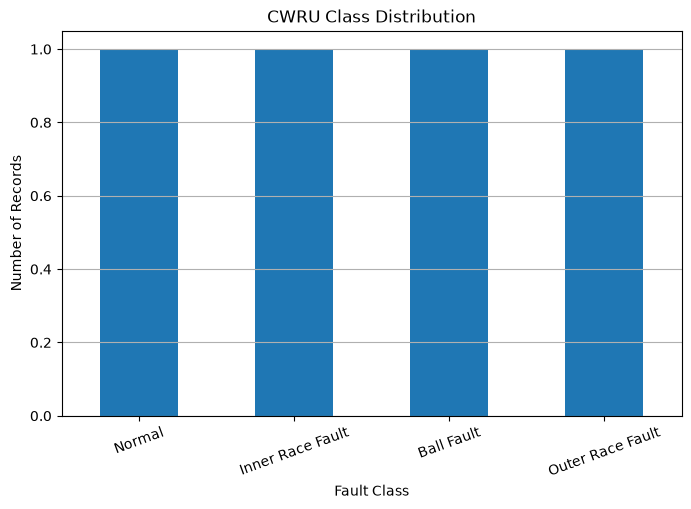

In [14]:
import matplotlib.pyplot as plt

print("=== CLASS DISTRIBUTION ===")
print(cwru_df["Label"].value_counts())

plt.figure(figsize=(8, 5))
cwru_df["Label"].value_counts().plot(kind="bar")

plt.xlabel("Fault Class")
plt.ylabel("Number of Records")
plt.title("CWRU Class Distribution")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

In [15]:
print("=== NUMERICAL FEATURE STATISTICS ===")

numeric_df = cwru_df.select_dtypes(include=np.number)

display(numeric_df.describe().T)

=== NUMERICAL FEATURE STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
RPM,4.0,1796.250000,0.500000,1796.000000,1796.000000,1796.000000,1796.250000,1797.000000
Sampling_Rate,4.0,12000.000000,0.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
Samples,4.0,152441.250000,61000.173182,121265.000000,121809.500000,122281.000000,152912.750000,243938.000000
Duration,4.0,12.703438,5.083348,10.105417,10.150792,10.190083,12.742729,20.328167
Mean,4.0,0.015445,0.005167,0.012558,0.012595,0.013025,0.015876,0.023171
Median,4.0,0.013606,0.006131,0.007147,0.011174,0.012675,0.015106,0.021929
Std,4.0,0.292917,0.266968,0.072687,0.122168,0.214939,0.385688,0.669104
Min,4.0,-1.420561,1.402615,-3.408701,-1.887090,-0.993453,-0.526924,-0.286638
Max,4.0,1.571161,1.504620,0.311254,0.530764,1.171482,2.211879,3.630425
RMS,4.0,0.293507,0.266750,0.073764,0.122866,0.215380,0.386021,0.669506


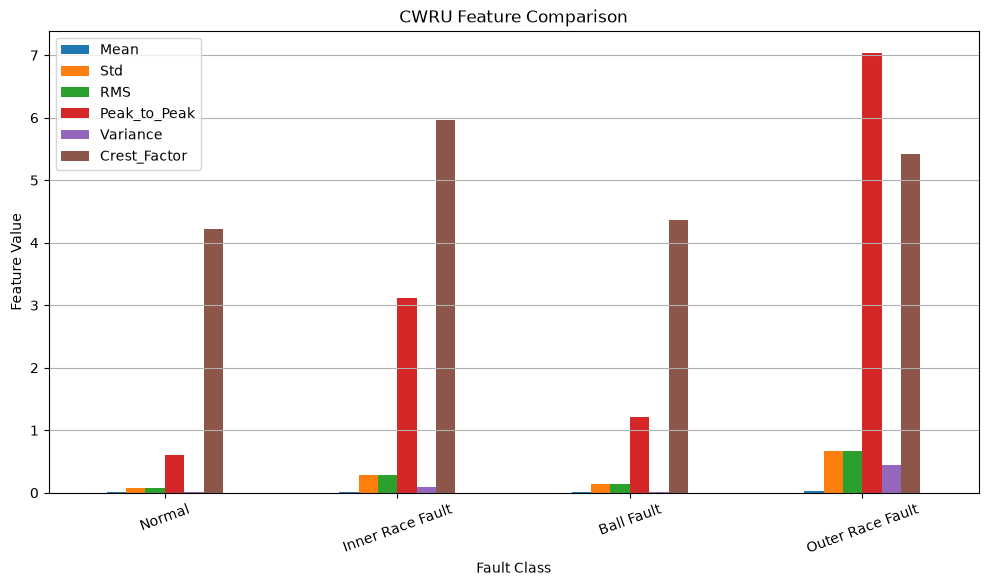

In [16]:
features_to_plot = [
    "Mean",
    "Std",
    "RMS",
    "Peak_to_Peak",
    "Variance",
    "Crest_Factor"
]

cwru_df.plot(
    x="Label",
    y=features_to_plot,
    kind="bar",
    figsize=(12, 6)
)

plt.title("CWRU Feature Comparison")
plt.xlabel("Fault Class")
plt.ylabel("Feature Value")
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

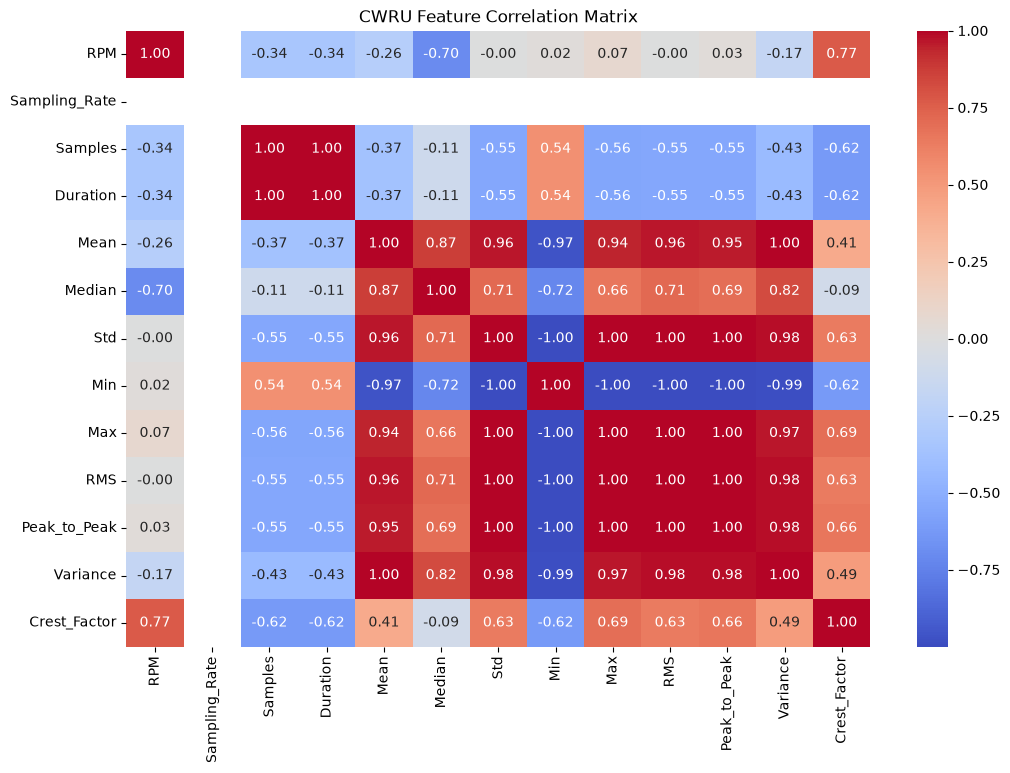

In [17]:
import seaborn as sns

plt.figure(figsize=(12, 8))

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("CWRU Feature Correlation Matrix")
plt.show()

In [18]:
output_path = r"C:\MachineHealthProject\processed\CWRU_processed.csv"

cwru_df.to_csv(output_path, index=False)

print("CWRU processed dataset saved successfully:")
print(output_path)

CWRU processed dataset saved successfully:
C:\MachineHealthProject\processed\CWRU_processed.csv
